<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

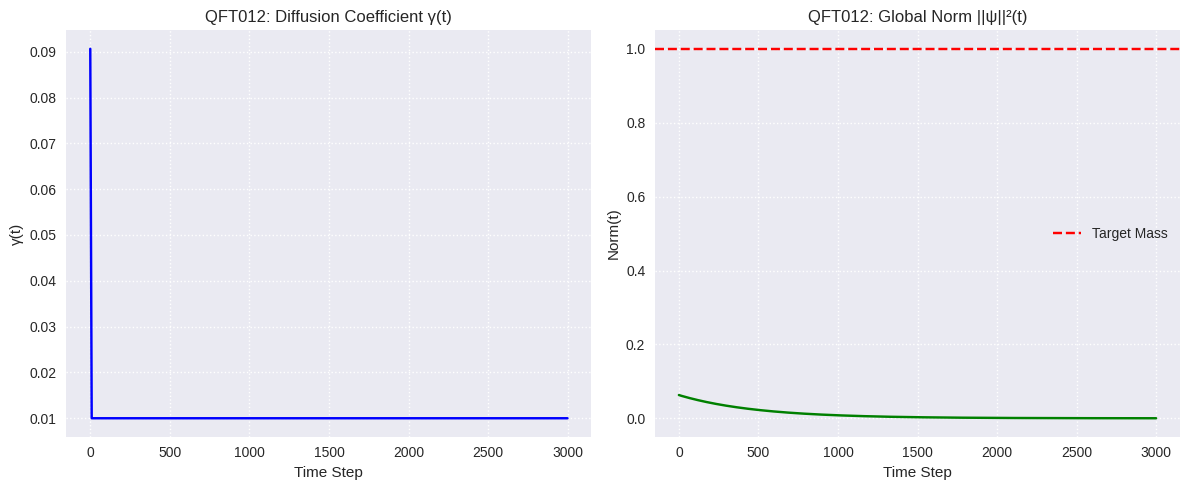

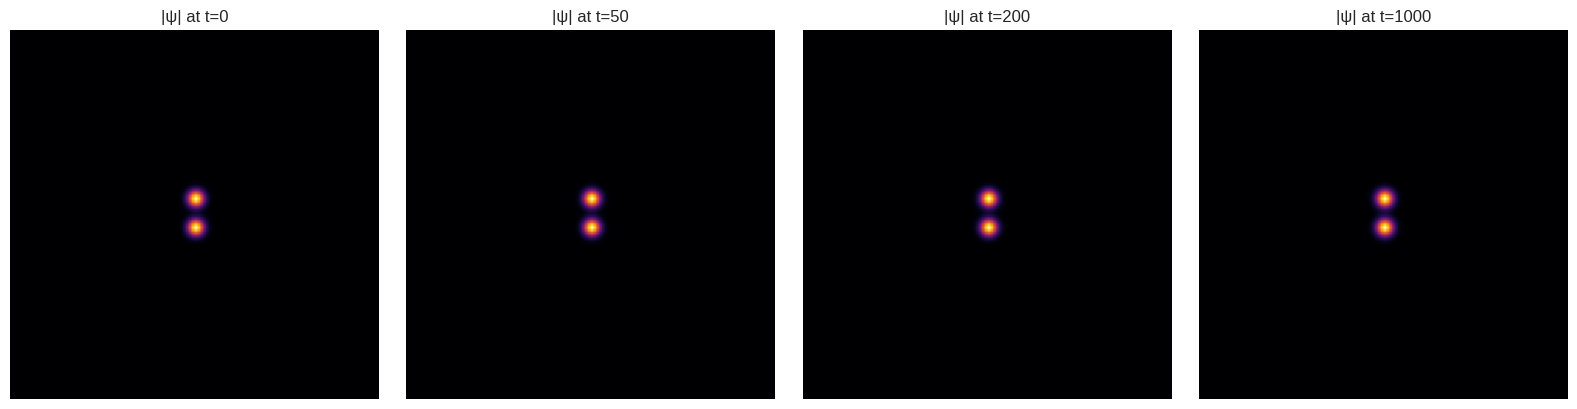

In [3]:
# QFT012: Emergence of Diffusion — Stabilized Version
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N_grid = 128
T = 3000
dt = 0.01
delta = 0.05
kappa = 0.1
eta = 0.01
m_T = 1.0
gamma_min = 0.01
gamma_max = 1.0

# Grid setup
x = np.arange(N_grid)
y = np.arange(N_grid)
X, Y = np.meshgrid(x, y, indexing='ij')

# Initial attractors
def gaussian(x0, y0, width=2.0, amp=0.05):
    return amp * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * width**2))

x1, y1 = N_grid//2 - 5, N_grid//2
x2, y2 = N_grid//2 + 5, N_grid//2
psi = (gaussian(x1, y1) + gaussian(x2, y2)).astype(np.complex128)

# FFT kernel
kx = np.fft.fftfreq(N_grid) * (2 * np.pi)
ky = np.fft.fftfreq(N_grid) * (2 * np.pi)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
laplacian_kernel = -(KX**2 + KY**2)

# Trackers
gamma_t = []
norm_t = []
snapshots = []

# Initial gamma
gamma = 0.1

# Evolution loop
for t in range(T):
    norm = np.sum(np.abs(psi)**2)
    gamma = np.clip(gamma + eta * (norm - m_T), gamma_min, gamma_max)

    restoring = -kappa * psi
    reaction = delta * np.abs(psi)**2 * psi
    rhs = psi + dt * (restoring + reaction)

    rhs_fft = np.fft.fft2(rhs)
    implicit_denominator = 1 - dt * gamma * laplacian_kernel
    psi_fft = rhs_fft / implicit_denominator
    psi = np.fft.ifft2(psi_fft)

    gamma_t.append(gamma)
    norm_t.append(norm)

    if t in [0, 50, 200, 1000]:
        snapshots.append(np.abs(psi))

# Plot gamma(t) and Norm(t)
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(gamma_t, color='blue')
axs[0].set_title('QFT012: Diffusion Coefficient γ(t)')
axs[0].set_xlabel('Time Step')
axs[0].set_ylabel('γ(t)')
axs[0].grid(True, linestyle=':')

axs[1].plot(norm_t, color='green')
axs[1].set_title('QFT012: Global Norm ||ψ||²(t)')
axs[1].set_xlabel('Time Step')
axs[1].set_ylabel('Norm(t)')
axs[1].axhline(m_T, color='red', linestyle='--', label='Target Mass')
axs[1].legend()
axs[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

# Plot snapshots of ψ(t)
fig2, axes2 = plt.subplots(1, len(snapshots), figsize=(16, 4))
for i, snap in enumerate(snapshots):
    axes2[i].imshow(snap, cmap='inferno', origin='lower')
    axes2[i].set_title(f'|ψ| at t={ [0, 50, 200, 1000][i] }')
    axes2[i].axis('off')

plt.tight_layout()
plt.show()
